In [2]:
%pip install opencv-python matplotlib

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 6.0 MB/s eta 0:00:08
   - -------------------------------------- 1.3/44.0 MB 3.5 MB/s eta 0:00:13
   - -------------------------------------- 1.8/44.0 MB 3.8 MB/s eta 0:00:12
   -- ------------------------------------- 2.6/44.0 MB 3.4 MB/s eta 0:00:13
   --- ------------------------------------ 3.4/44.0 MB 3.4 MB/s eta 0:00:13
   --- ------------------------------------ 4.2/44.0 MB 3.5 MB/s eta 0:00:12
   ---- ----------------------------------- 5.0/44.0 MB 3.5 MB/s eta 0:00:12
   ----- ---------------------------------- 6.0/44.0 MB 3.7 MB/s eta 0:00:11
   ------ --------------------------------- 6.8/44.0 MB 3.8 MB/s eta 0:00:10
   ------ --------------------------------- 7.3/44.0 MB 3.6 MB/s eta 0:00:11
   ------- -------------------------------- 8.1/44.0 MB 3.6 MB/s eta 0:00:10
   -------- ------------------------------- 8.9/44.0 MB 3.7 MB/s eta 0:00:10
   ---

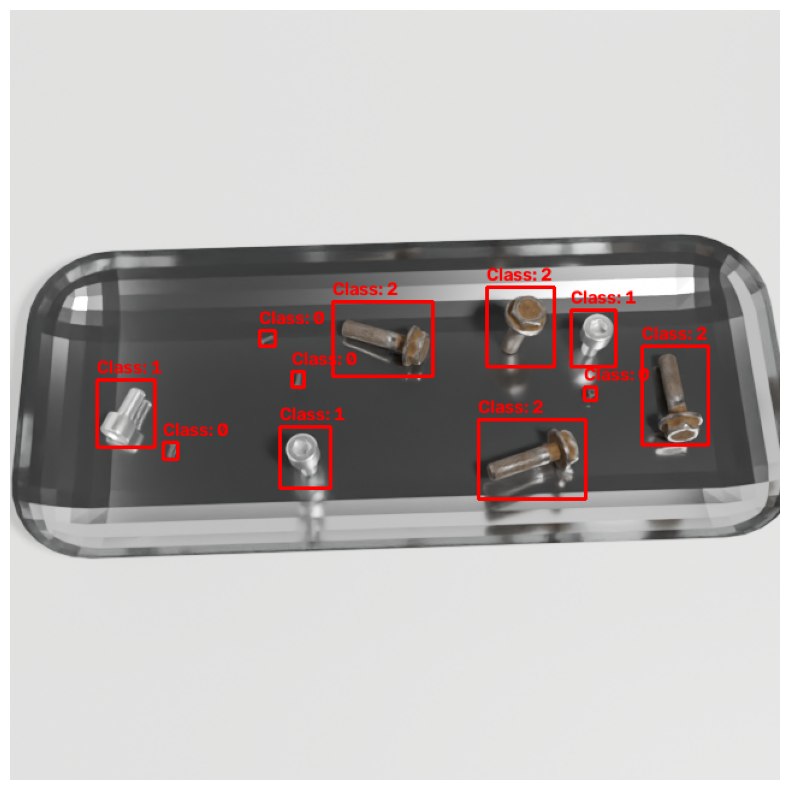

In [3]:
import cv2
import matplotlib.pyplot as plt

# Coloque o caminho exato de uma imagem e seu respectivo txt que acabaram de ser gerados
img_path = r"C:\Users\rafae\DocumentsPC\dataset\train\images\img_0000.png"
txt_path = r"C:\Users\rafae\DocumentsPC\dataset\train\labels\img_0000.txt"

# Carrega a imagem
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Lê o arquivo txt e desenha as caixas
with open(txt_path, 'r') as f:
    for line in f:
        # Extrai os 5 valores do formato YOLO
        class_id, xc, yc, bw, bh = map(float, line.split())
        
        # Converte os valores normalizados (0 a 1) para pixels reais da imagem
        x_center, y_center = int(xc * w), int(yc * h)
        box_w, box_h = int(bw * w), int(bh * h)
        
        x_min = int(x_center - box_w / 2)
        y_min = int(y_center - box_h / 2)
        x_max = int(x_center + box_w / 2)
        y_max = int(y_center + box_h / 2)
        
        # Desenha o retângulo vermelho e o ID da classe
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
        cv2.putText(img, f"Class: {int(class_id)}", (x_min, y_min - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Mostra o resultado
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()